In [1]:
from itertools import combinations

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE, trustworthiness
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    pairwise_distances,
    silhouette_score,
    euclidean_distances
)
from sklearn.model_selection import ParameterGrid
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler, StandardScaler
from kmedoids import KMedoids




In [2]:
data_raw = pd.read_csv('Elektrines_duomenys_2023-2024m.csv', sep=';', decimal=',')
data_selected_features= data_raw[["timestamp"] + [f"Total_active_power_INV-{i}" for i in range(1, 9)]]
inv_cols = [c for c in data_selected_features.columns if c != "timestamp"]
data_selected_features["timestamp"] = pd.to_datetime(data_selected_features["timestamp"])
data_selected_features








,timestamp,Total_active_power_INV-1,Total_active_power_INV-2,Total_active_power_INV-3,Total_active_power_INV-4,Total_active_power_INV-5,Total_active_power_INV-6,Total_active_power_INV-7,Total_active_power_INV-8
0,2023-01-01 00:00:00,0.067,0.0,NaN,0.019,0.021,0.056,0.039,0.041
1,2023-01-01 00:05:00,0.067,0.0,NaN,0.019,0.021,0.056,0.039,0.041
2,2023-01-01 00:10:00,0.067,0.0,NaN,0.019,0.021,0.056,0.039,0.041
3,2023-01-01 00:15:00,0.067,0.0,NaN,0.019,0.021,0.056,0.039,0.041
4,2023-01-01 00:20:00,0.067,0.0,NaN,0.019,0.021,0.056,0.039,0.041
...,...,...,...,...,...,...,...,...,...
210511,2024-12-31 22:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210512,2024-12-31 22:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210513,2024-12-31 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210514,2024-12-31 22:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
mask_all_na = data_selected_features[inv_cols].isna().all(axis=1)
all_empty=data_selected_features[mask_all_na]
all_empty["day"] = all_empty["timestamp"].dt.date
all_empty = all_empty[(all_empty["timestamp"].dt.hour >= 2) & (all_empty["timestamp"].dt.hour < 19)]
all_empty["count_per_day"] = all_empty.groupby("day")["timestamp"].transform("size")
all_empty








,timestamp,Total_active_power_INV-1,Total_active_power_INV-2,Total_active_power_INV-3,Total_active_power_INV-4,Total_active_power_INV-5,Total_active_power_INV-6,Total_active_power_INV-7,Total_active_power_INV-8,day,count_per_day
35889,2023-05-05 14:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-05,1
109878,2024-01-17 12:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-17,15
109879,2024-01-17 12:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-17,15
109880,2024-01-17 12:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-17,15
109881,2024-01-17 12:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-17,15
...,...,...,...,...,...,...,...,...,...,...,...
210463,2024-12-31 18:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-31,108
210464,2024-12-31 18:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-31,108
210465,2024-12-31 18:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-31,108
210466,2024-12-31 18:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-31,108


       Inverteris 2024 metais išsijungia random nuo 19:00 iki 02:00, todėl stebėjome keistumus, bet čia problemų yra ir kitų - skaityk duomenų kiekis atitinkantis 17 dienų yra tušti;

In [4]:
data_selected_features=data_selected_features[data_selected_features["timestamp"].dt.year == 2023]








    <span style="color: rgb(244, 12, 105);">  Daug geriau yra su praleistomis reikšmėmis -- čia yra tik viena diena kur visi inverteriai, jei imame tik 2023 metus, čia problema yra tik su 3 inverteriu, NA reikšmes čia užpildydami vidurkiu visai gerą aproksimacija gaunasi mano galva;

In [5]:
mask_all_na_2023 = data_selected_features[inv_cols].isna().all(axis=1)
all_empty_2023=data_selected_features[mask_all_na_2023]
all_empty_2023








,timestamp,Total_active_power_INV-1,Total_active_power_INV-2,Total_active_power_INV-3,Total_active_power_INV-4,Total_active_power_INV-5,Total_active_power_INV-6,Total_active_power_INV-7,Total_active_power_INV-8
35889,2023-05-05 14:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
data_raw = data_selected_features[~mask_all_na_2023]
data_raw








,timestamp,Total_active_power_INV-1,Total_active_power_INV-2,Total_active_power_INV-3,Total_active_power_INV-4,Total_active_power_INV-5,Total_active_power_INV-6,Total_active_power_INV-7,Total_active_power_INV-8
0,2023-01-01 00:00:00,0.067,0.0,NaN,0.019,0.021,0.056,0.039,0.041
1,2023-01-01 00:05:00,0.067,0.0,NaN,0.019,0.021,0.056,0.039,0.041
2,2023-01-01 00:10:00,0.067,0.0,NaN,0.019,0.021,0.056,0.039,0.041
3,2023-01-01 00:15:00,0.067,0.0,NaN,0.019,0.021,0.056,0.039,0.041
4,2023-01-01 00:20:00,0.067,0.0,NaN,0.019,0.021,0.056,0.039,0.041
...,...,...,...,...,...,...,...,...,...
105115,2023-12-31 23:35:00,0.000,0.0,0.0,0.019,0.021,0.039,0.039,0.041
105116,2023-12-31 23:40:00,0.000,0.0,0.0,0.019,0.021,0.039,0.039,0.041
105117,2023-12-31 23:45:00,0.000,0.0,0.0,0.019,0.021,0.039,0.039,0.041
105118,2023-12-31 23:50:00,0.000,0.0,0.0,0.019,0.021,0.039,0.039,0.041


        Turime su 3 inverteriu daug praleistų reikšmelių (56 dienas) siūlau trinti, kol kas užpildau vidurkiu pagal eilutes

In [7]:
data_raw[inv_cols] = data_raw[inv_cols].apply(lambda row: row.fillna(row.mean()), axis=1)
data_raw


,timestamp,Total_active_power_INV-1,Total_active_power_INV-2,Total_active_power_INV-3,Total_active_power_INV-4,Total_active_power_INV-5,Total_active_power_INV-6,Total_active_power_INV-7,Total_active_power_INV-8
0,2023-01-01 00:00:00,0.067,0.0,0.034714,0.019,0.021,0.056,0.039,0.041
1,2023-01-01 00:05:00,0.067,0.0,0.034714,0.019,0.021,0.056,0.039,0.041
2,2023-01-01 00:10:00,0.067,0.0,0.034714,0.019,0.021,0.056,0.039,0.041
3,2023-01-01 00:15:00,0.067,0.0,0.034714,0.019,0.021,0.056,0.039,0.041
4,2023-01-01 00:20:00,0.067,0.0,0.034714,0.019,0.021,0.056,0.039,0.041
...,...,...,...,...,...,...,...,...,...
105115,2023-12-31 23:35:00,0.000,0.0,0.000000,0.019,0.021,0.039,0.039,0.041
105116,2023-12-31 23:40:00,0.000,0.0,0.000000,0.019,0.021,0.039,0.039,0.041
105117,2023-12-31 23:45:00,0.000,0.0,0.000000,0.019,0.021,0.039,0.039,0.041
105118,2023-12-31 23:50:00,0.000,0.0,0.000000,0.019,0.021,0.039,0.039,0.041


In [8]:
data_raw["Total_active_power"] = data_raw[[f"Total_active_power_INV-{i}" for i in range(1, 9)]].sum(axis=1)
data_summed= data_raw[["timestamp", "Total_active_power"]]
data_summed


,timestamp,Total_active_power
0,2023-01-01 00:00:00,0.277714
1,2023-01-01 00:05:00,0.277714
2,2023-01-01 00:10:00,0.277714
3,2023-01-01 00:15:00,0.277714
4,2023-01-01 00:20:00,0.277714
...,...,...
105115,2023-12-31 23:35:00,0.159000
105116,2023-12-31 23:40:00,0.159000
105117,2023-12-31 23:45:00,0.159000
105118,2023-12-31 23:50:00,0.159000


In [9]:
data_summed.isna().sum()



timestamp             0
Total_active_power    0
dtype: int64

In [10]:
data_summed["Day"] = data_summed["timestamp"].dt.date
data_summed["Hour"] = data_summed["timestamp"].dt.floor("h").dt.strftime("%H:%M")
data_summed=data_summed[(data_summed["Hour"] <= "19:00") & (data_summed["Hour"] >= "01:00")]
sum_of_inv = (
    data_summed.groupby(["Day", "Hour"], as_index=False)["Total_active_power"]
    .sum()
)
sum_of_inv_wide = sum_of_inv.pivot(index="Day", columns="Hour", values="Total_active_power")
sum_of_inv_wide.columns.name = None  
sum_of_inv_wide = sum_of_inv_wide.reset_index()

final_dataset = sum_of_inv_wide[["Day"] + sorted(sum_of_inv_wide.columns[1:])]
data_summed



,timestamp,Total_active_power,Day,Hour
12,2023-01-01 01:00:00,0.277714,2023-01-01,01:00
13,2023-01-01 01:05:00,0.277714,2023-01-01,01:00
14,2023-01-01 01:10:00,0.277714,2023-01-01,01:00
15,2023-01-01 01:15:00,0.277714,2023-01-01,01:00
16,2023-01-01 01:20:00,0.277714,2023-01-01,01:00
...,...,...,...,...
105067,2023-12-31 19:35:00,0.159000,2023-12-31,19:00
105068,2023-12-31 19:40:00,0.159000,2023-12-31,19:00
105069,2023-12-31 19:45:00,0.159000,2023-12-31,19:00
105070,2023-12-31 19:50:00,0.159000,2023-12-31,19:00


In [11]:
final_dataset["month"] = pd.to_datetime(final_dataset["Day"]).dt.month



In [12]:
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

final_dataset["season"] = final_dataset["month"].map(season_map)








C:\Users\danie\AppData\Local\Temp\ipykernel_40784\2225346432.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


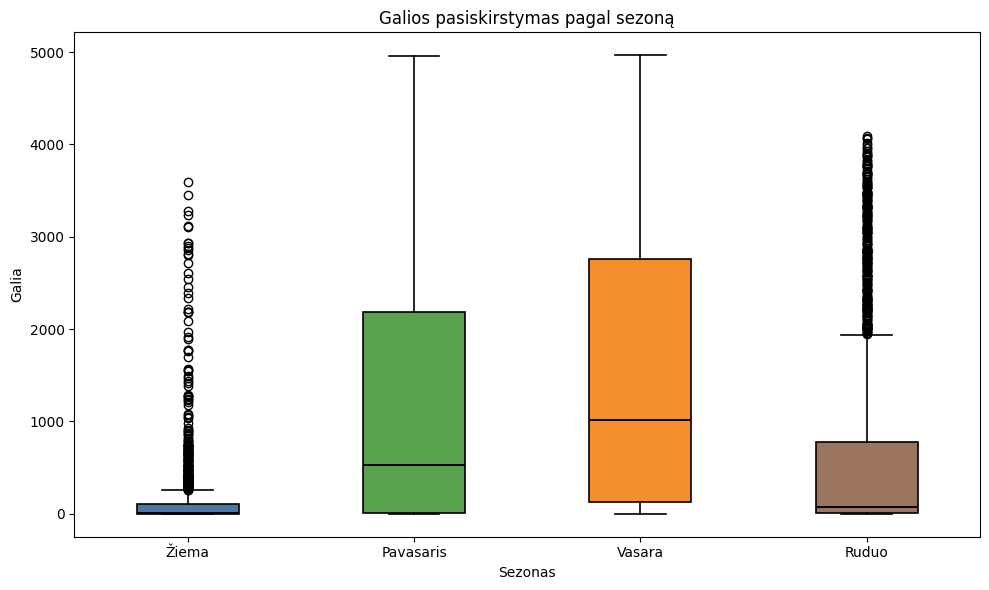

In [13]:
season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_colors = ["#4C78A8", "#59A14F", "#F28E2B", "#9C755F"]

id_cols = ["Day", "month", "season"]
value_cols = [c for c in final_dataset.columns if c not in id_cols]

final_dataset_melted = final_dataset.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name="time",
    value_name="power"
)

data_by_season = [
    final_dataset_melted.loc[final_dataset_melted["season"] == s, "power"].values
    for s in season_order
]
sezonai=["Žiema", "Pavasaris", "Vasara", "Ruduo"]

plt.figure(figsize=(10, 6))
bp = plt.boxplot(
    data_by_season,
    labels=sezonai,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.4},
    boxprops={"linewidth": 1.2},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2}
)

for box, color in zip(bp["boxes"], season_colors):
    box.set_facecolor(color)

plt.title("Galios pasiskirstymas pagal sezoną")
plt.xlabel("Sezonas")
plt.ylabel("Galia")
plt.tight_layout()
plt.show()








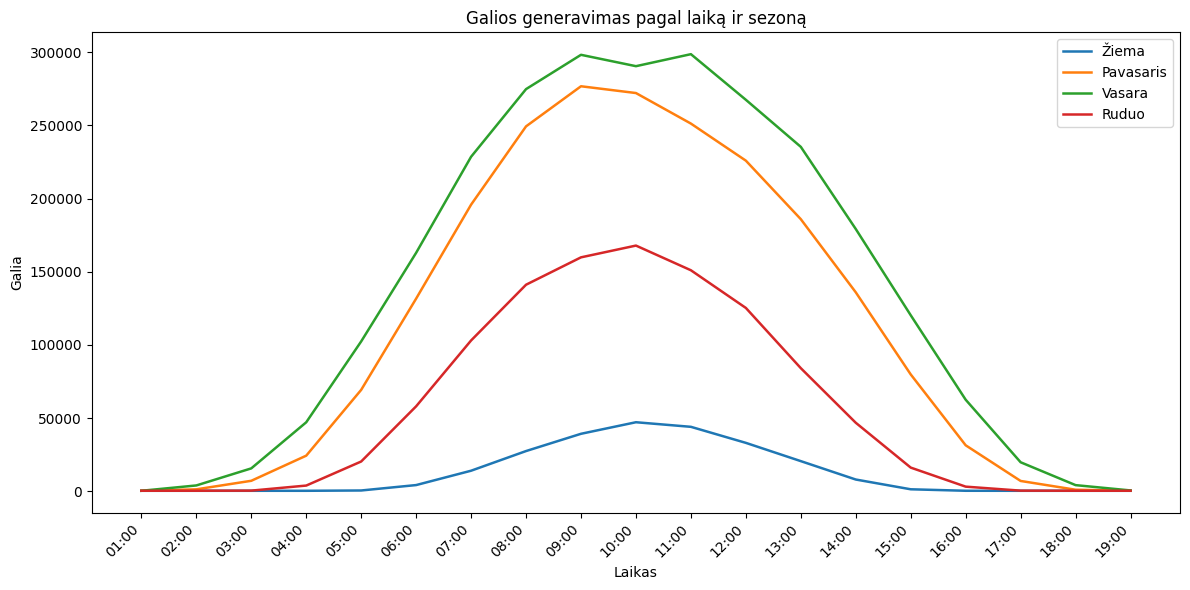

In [14]:
final_dataset_melted["time_dt"] = pd.to_datetime(final_dataset_melted["time"], format="%H:%M", errors="coerce")
line_df = (
    final_dataset_melted
    .groupby(["season", "time", "time_dt"], as_index=False)["power"]
    .sum()
    .sort_values("time_dt")
)
season_labels_lt = {
    "Winter": "Žiema",
    "Spring": "Pavasaris",
    "Summer": "Vasara",
    "Autumn": "Ruduo",
}
season_order = ["Winter", "Spring", "Summer", "Autumn"]
plt.figure(figsize=(12, 6))
for s in season_order:
    part = line_df[line_df["season"] == s]
    plt.plot(
        part["time"],
        part["power"],
        label=season_labels_lt.get(s, s),
        linewidth=1.8
    )
plt.title("Galios generavimas pagal laiką ir sezoną")
plt.xlabel("Laikas")
plt.ylabel("Galia")
plt.xticks(ticks=range(0, len(part["time"])), rotation=45, ha="right") 
plt.legend()
plt.tight_layout()
plt.show()











        Patriminau laiką;

In [15]:
print(final_dataset.head())
print("#" * 50)
print(final_dataset_melted.head())








          Day     01:00     02:00     03:00     04:00     05:00     06:00  \
0  2023-01-01  3.332571  3.332571  3.332571  3.332571  3.332571  2.122286   
1  2023-01-02  1.179429  1.179429  1.179429  1.179429  1.179429  1.325714   
2  2023-01-03  2.811429  2.811429  2.811429  2.811429  2.811429  9.208000   
3  2023-01-04  2.194286  2.194286  2.194286  2.194286  2.194286  2.938286   
4  2023-01-05  1.330286  1.330286  1.330286  1.330286  1.330286  0.665143   

        07:00       08:00       09:00  ...       12:00      13:00     14:00  \
0  135.002286  609.012571  657.556571  ...  256.371429  50.338286  5.506286   
1   60.340571  147.164571  234.304000  ...   60.052571  24.674286  5.404571   
2  169.184000  614.890286  527.333714  ...  173.658286  53.118857  8.201143   
3  146.043429  681.236571  403.397714  ...  327.083429  83.434286  7.072000   
4   40.764571   99.144000  184.892571  ...   91.618286  26.621714  7.213714   

      15:00     16:00     17:00     18:00     19:00  month  se

In [16]:
id_cols = ["Day", "month", "season"]
value_cols = [c for c in final_dataset.columns if c not in id_cols]
scaler = RobustScaler()
final_dataset_scaled = final_dataset.copy()
final_dataset_scaled[value_cols] = scaler.fit_transform(final_dataset[value_cols])
final_dataset_melted_scaled = final_dataset_scaled.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name="time",
    value_name="power"
)








In [17]:
final_dataset_scaled








,Day,01:00,02:00,03:00,04:00,05:00,06:00,07:00,08:00,09:00,...,12:00,13:00,14:00,15:00,16:00,17:00,18:00,19:00,month,season
0,2023-01-01,0.287692,0.031797,-0.002469,-0.118906,-0.256095,-0.356528,-0.396710,-0.406067,-0.436178,...,-0.402404,-0.396253,-0.306995,-0.242798,-0.071172,-0.026300,-0.335510,-1.441244,1,Winter
1,2023-01-02,-1.574889,-1.028491,-0.022493,-0.124818,-0.258279,-0.356964,-0.425814,-0.559676,-0.566106,...,-0.472563,-0.406789,-0.307052,-0.241268,-0.067820,-0.011467,-0.102367,-0.344470,1,Winter
2,2023-01-03,-0.163124,-0.224833,-0.007315,-0.120337,-0.256623,-0.352646,-0.383386,-0.404113,-0.476153,...,-0.431963,-0.395111,-0.305472,-0.241847,-0.069087,-0.017076,-0.190531,-0.759217,1,Winter
3,2023-01-04,-0.696985,-0.528737,-0.013055,-0.122032,-0.257250,-0.356081,-0.392406,-0.382046,-0.514199,...,-0.377133,-0.382665,-0.306110,-0.242657,-0.070862,-0.024929,-0.313959,-1.339862,1,Winter
4,2023-01-05,-1.444390,-0.954203,-0.021090,-0.124404,-0.258126,-0.357326,-0.433446,-0.575648,-0.581274,...,-0.461282,-0.405990,-0.306030,-0.241204,-0.067679,-0.010844,-0.092571,-0.298387,1,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2023-12-27,-1.121107,-0.770172,-0.017614,-0.123322,-0.257750,-0.357270,-0.413544,-0.421005,-0.422035,...,-0.369588,-0.357172,-0.303193,-0.240641,-0.066446,-0.005391,-0.006857,0.104839,12,Winter
361,2023-12-28,0.415225,0.104397,-0.001097,-0.118502,-0.255945,-0.356430,-0.417185,-0.561594,-0.544740,...,-0.442499,-0.405081,-0.306920,-0.240270,-0.065633,-0.001792,0.049714,0.370968,12,Winter
362,2023-12-29,0.757785,0.299402,0.002585,-0.117414,-0.255543,-0.356566,-0.410519,-0.540510,-0.582274,...,-0.472204,-0.404408,-0.306538,-0.241609,-0.068566,-0.014771,-0.154286,-0.588710,12,Winter
363,2023-12-30,-0.477509,-0.403799,-0.010695,-0.121335,-0.256992,-0.356703,-0.443876,-0.553544,-0.542008,...,-0.451362,-0.397613,-0.305488,-0.241136,-0.067531,-0.010190,-0.082286,-0.250000,12,Winter


In [18]:
final_dataset_melted_scaled








,Day,month,season,time,power
0,2023-01-01,1,Winter,01:00,0.287692
1,2023-01-02,1,Winter,01:00,-1.574889
2,2023-01-03,1,Winter,01:00,-0.163124
3,2023-01-04,1,Winter,01:00,-0.696985
4,2023-01-05,1,Winter,01:00,-1.444390
...,...,...,...,...,...
6930,2023-12-27,12,Winter,19:00,0.104839
6931,2023-12-28,12,Winter,19:00,0.370968
6932,2023-12-29,12,Winter,19:00,-0.588710
6933,2023-12-30,12,Winter,19:00,-0.250000


C:\Users\danie\AppData\Local\Temp\ipykernel_40784\3248706832.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


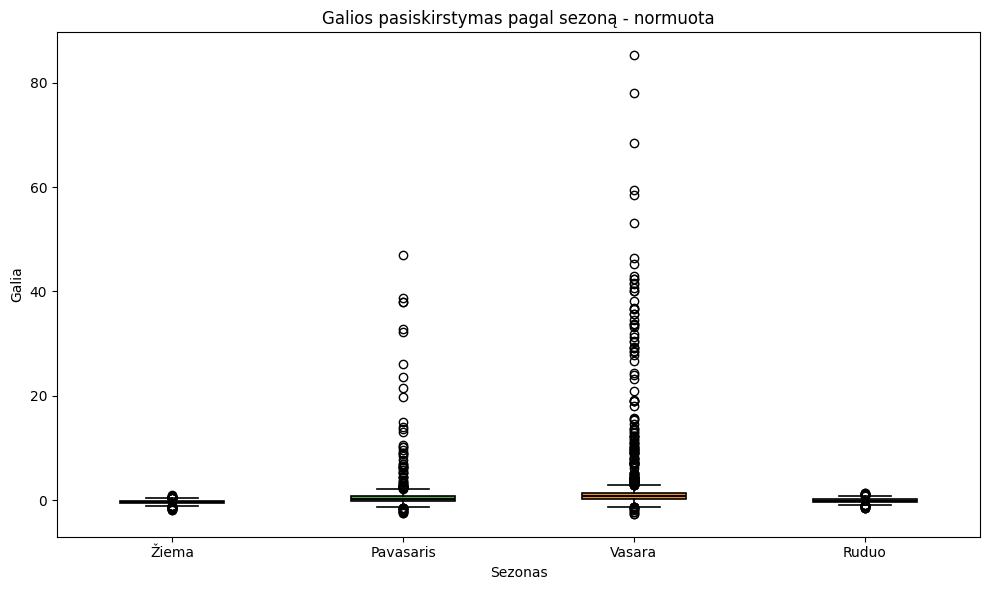

In [19]:
data_by_season = [
    final_dataset_melted_scaled.loc[final_dataset_melted_scaled["season"] == s, "power"].values
    for s in season_order
]
sezonai=["Žiema", "Pavasaris", "Vasara", "Ruduo"]

plt.figure(figsize=(10, 6))
bp = plt.boxplot(
    data_by_season,
    labels=sezonai,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.4},
    boxprops={"linewidth": 1.2},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2}
)

for box, color in zip(bp["boxes"], season_colors):
    box.set_facecolor(color)

plt.title("Galios pasiskirstymas pagal sezoną - normuota")
plt.xlabel("Sezonas")
plt.ylabel("Galia")
plt.tight_layout()
plt.show()








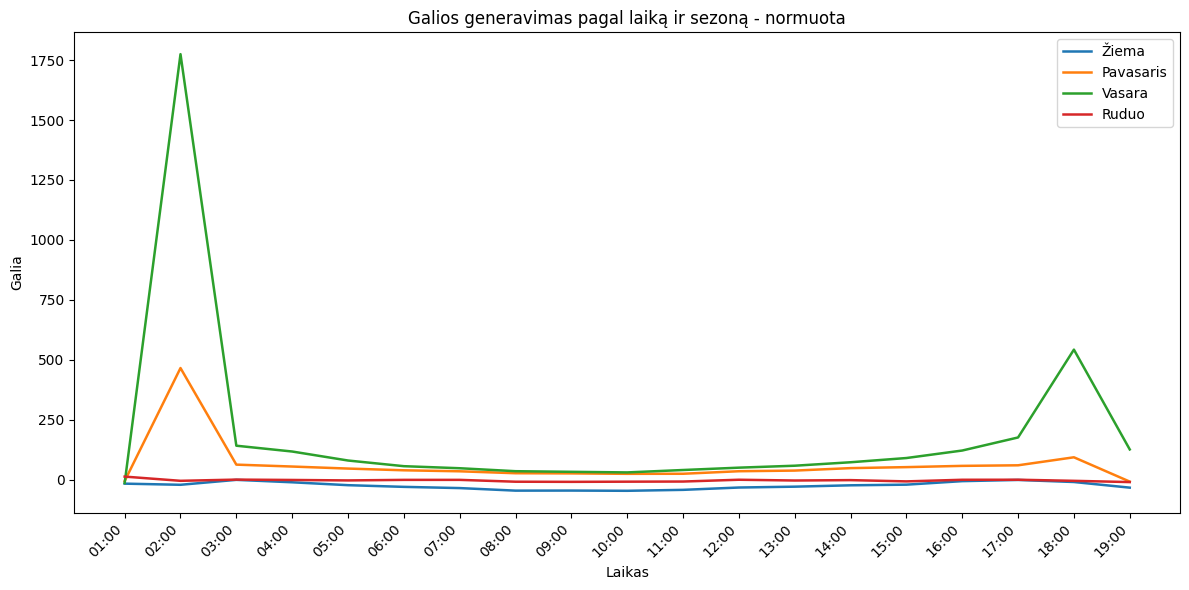

In [20]:
final_dataset_melted_scaled["time_dt"] = pd.to_datetime(final_dataset_melted_scaled["time"], format="%H:%M", errors="coerce")
line_df = (
    final_dataset_melted_scaled	
    .groupby(["season", "time", "time_dt"], as_index=False)["power"]
    .sum()
    .sort_values("time_dt")
)
season_labels_lt = {
    "Winter": "Žiema",
    "Spring": "Pavasaris",
    "Summer": "Vasara",
    "Autumn": "Ruduo",
}
season_order = ["Winter", "Spring", "Summer", "Autumn"]
plt.figure(figsize=(12, 6))
for s in season_order:
    part = line_df[line_df["season"] == s]
    plt.plot(
        part["time"],
        part["power"],
        label=season_labels_lt.get(s, s),
        linewidth=1.8
    )
plt.title("Galios generavimas pagal laiką ir sezoną - normuota")
plt.xlabel("Laikas")
plt.ylabel("Galia")
plt.xticks(ticks=range(0, len(part["time"])), rotation=45, ha="right") 
plt.legend()
plt.tight_layout()
plt.show()











In [21]:
print(final_dataset_melted[["power","season"]].groupby("season").describe())









         power                                                          \
         count         mean          std    min         25%        50%   
season                                                                   
Autumn  1729.0   625.795825  1017.423407  0.651    3.372000    69.0040   
Spring  1748.0  1227.772580  1445.678436  0.209   13.342500   531.6940   
Summer  1748.0  1494.316683  1454.160101  0.000  125.868500  1016.7505   
Winter  1710.0   140.997060   391.586957  0.000    2.729143     3.6720   

                               
                75%       max  
season                         
Autumn   779.437000  4092.732  
Spring  2185.774250  4960.276  
Summer  2759.239000  4965.673  
Winter   105.570571  3589.426  


In [22]:
print(final_dataset_melted_scaled[["power","season"]].groupby("season").describe())









         power                                                              \
         count      mean       std       min       25%       50%       75%   
season                                                                       
Autumn  1729.0 -0.033787  0.366486 -1.546713 -0.273829 -0.062749  0.165256   
Spring  1748.0  0.673575  2.738398 -2.395576 -0.060540  0.256854  0.837396   
Summer  1748.0  2.048461  6.492153 -2.595156  0.295509  0.727744  1.353327   
Winter  1710.0 -0.276453  0.283219 -1.841398 -0.443860 -0.268866 -0.068523   

                   
              max  
season             
Autumn   1.318339  
Spring  46.949982  
Summer  85.262117  
Winter   0.928324  


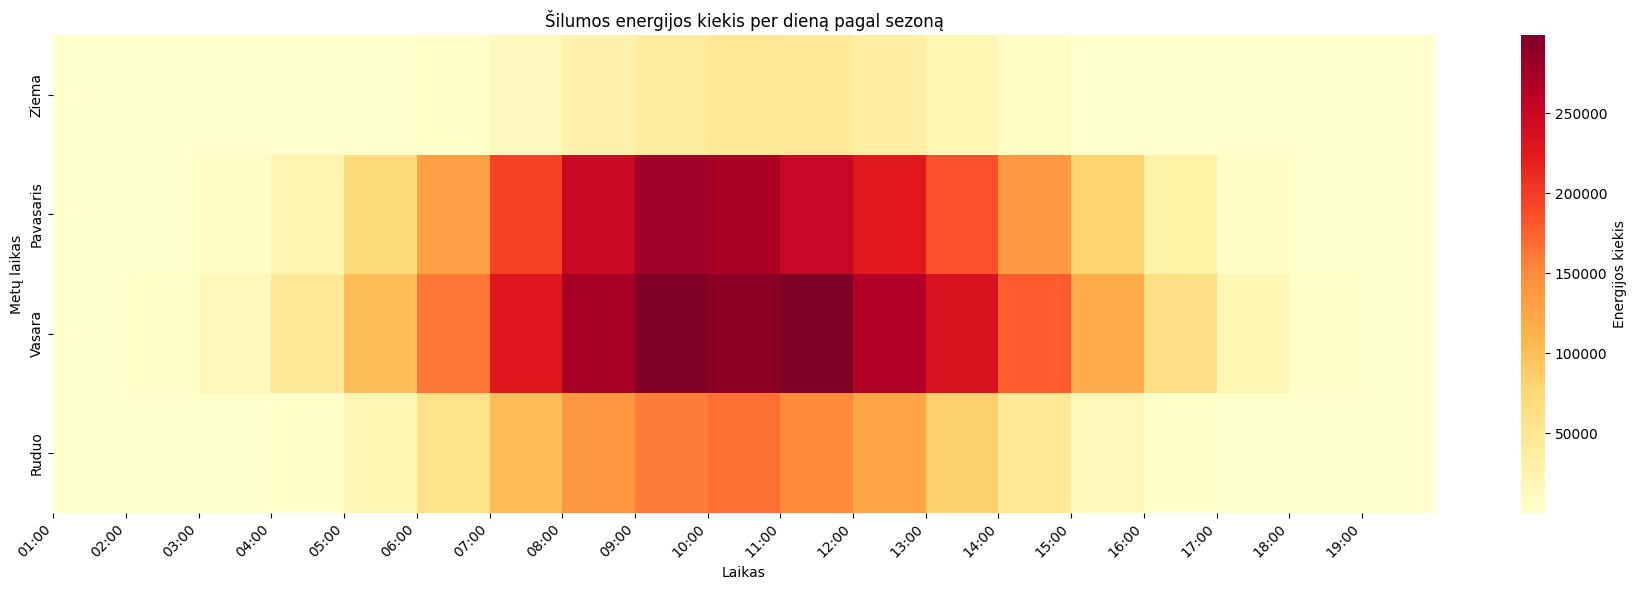

In [23]:

heatmap_by_season = (
    final_dataset_melted.groupby(["season", "time"], as_index=False)["power"]
    .sum()
    .pivot(index="season", columns="time", values="power")
    .reindex(season_order)
)

season_labels_lt = {
    "Winter": "Ziema",
    "Spring": "Pavasaris",
    "Summer": "Vasara",
    "Autumn": "Ruduo"
}
heatmap_by_season.index = [season_labels_lt.get(season, season) for season in heatmap_by_season.index]

plt.figure(figsize=(18, 6))
sns.heatmap(heatmap_by_season, cmap="YlOrRd", cbar_kws={"label": "Energijos kiekis"})
ax = plt.gca()

xtick_positions = range(0, len(heatmap_by_season.columns))
ax.set_xticks(xtick_positions)
ax.set_xticklabels(
    [heatmap_by_season.columns[i] for i in xtick_positions],
    rotation=45,
    ha="right"
)

plt.title("Šilumos energijos kiekis per dieną pagal sezoną")
plt.xlabel("Laikas")
plt.ylabel("Metų laikas")
plt.tight_layout()
plt.show()









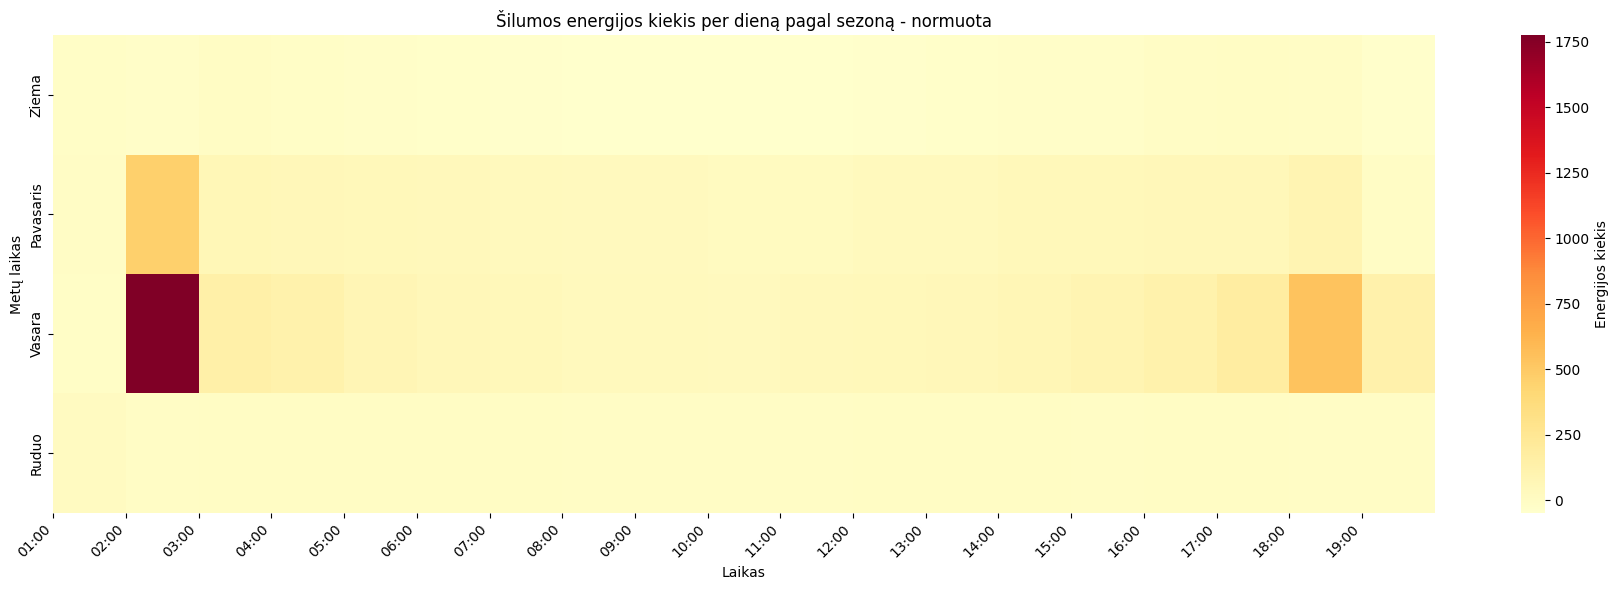

In [24]:

heatmap_by_season_scaled = (
    final_dataset_melted_scaled.groupby(["season", "time"], as_index=False)["power"]
    .sum()
    .pivot(index="season", columns="time", values="power")
    .reindex(season_order)
)

season_labels_lt = {
    "Winter": "Ziema",
    "Spring": "Pavasaris",
    "Summer": "Vasara",
    "Autumn": "Ruduo"
}
heatmap_by_season_scaled.index = [season_labels_lt.get(season, season) for season in heatmap_by_season_scaled.index]

plt.figure(figsize=(18, 6))
sns.heatmap(heatmap_by_season_scaled, cmap="YlOrRd", cbar_kws={"label": "Energijos kiekis"})
ax = plt.gca()

xtick_positions = range(0, len(heatmap_by_season_scaled.columns))
ax.set_xticks(xtick_positions)
ax.set_xticklabels(
    [heatmap_by_season_scaled.columns[i] for i in xtick_positions],
    rotation=45,
    ha="right"
)

plt.title("Šilumos energijos kiekis per dieną pagal sezoną - normuota")
plt.xlabel("Laikas")
plt.ylabel("Metų laikas")
plt.tight_layout()
plt.show()









In [25]:
final_dataset
id_cols







['Day', 'month', 'season']

In [26]:
X = final_dataset_scaled.drop(columns=id_cols).select_dtypes(include='number')








      ### PCA

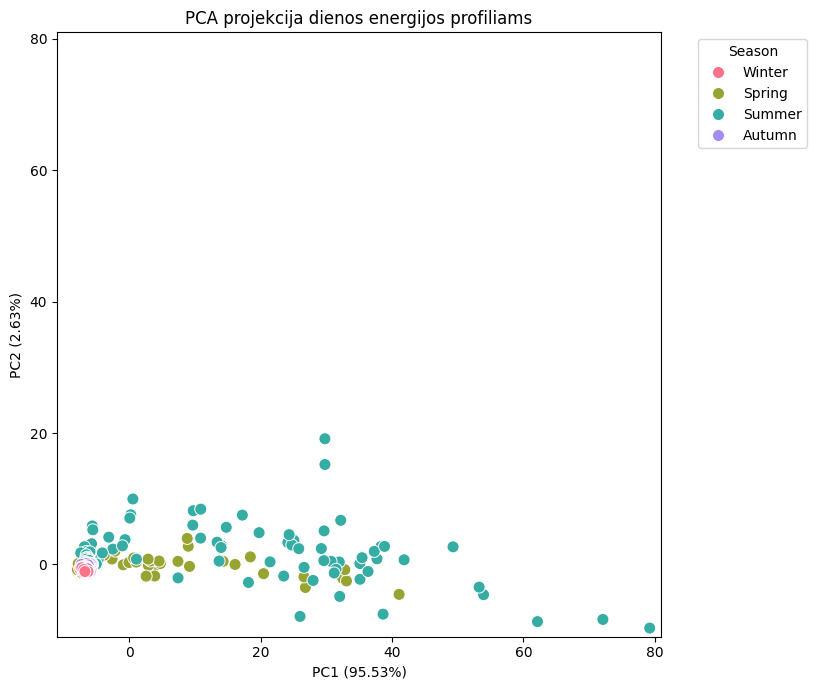

Explained variance ratio: [0.9553 0.0263]


In [27]:
pca_model = PCA(n_components=2, random_state=80085)
pca_result = pca_model.fit_transform(X)
X_pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
X_pca_df['season'] = final_dataset_scaled['season'].values


plt.figure(figsize=(10, 7))
lims = [
    min(np.floor(X_pca_df['PC1'].min()), np.floor(X_pca_df['PC2'].min())) - 1,
    max(np.ceil(X_pca_df['PC1'].max()), np.ceil(X_pca_df['PC2'].max())) + 1
]

plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')

sns.scatterplot(
    data=X_pca_df,
    x='PC1',
    y='PC2',
    hue='season',
    palette='husl',
    s=75,
    hue_order=['Winter', 'Spring', 'Summer', 'Autumn']
)

plt.title('PCA projekcija dienos energijos profiliams')
plt.xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]*100:.2f}%)')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Explained variance ratio:', np.round(pca_model.explained_variance_ratio_, 4))










In [28]:
def normalized_stress(X, X_emb):
	D_orig = pairwise_distances(X)
	D_emb = pairwise_distances(X_emb)
	return np.sum((D_orig - D_emb) ** 2) / np.sum(D_orig ** 2)







In [29]:
X_emb_pca = X_pca_df[['PC1', 'PC2']].values
t = trustworthiness(X.values, X_emb_pca, n_neighbors=10)
c = trustworthiness(X_emb_pca, X.values, n_neighbors=10)

D_orig = pairwise_distances(X.values)
D_emb = pairwise_distances(X_emb_pca)
stress = normalized_stress(X.values, X_emb_pca)

print(f"Trustworthiness: {t:.4f}")
print(f"Continuity: {c:.4f}")
print(f"Stress: {stress:.4f}")








Trustworthiness: 0.9399
Continuity: 0.9792
Stress: 0.0041


       ### T-SNE

































































































































In [30]:
# def tsne_grid_search(X, n=2, param_grid=None, n_neighbors=10, random_state=42):
#     grid = ParameterGrid(param_grid)
#     results = []
#     for params in grid:
#         tsne = TSNE(n_components=n, random_state=random_state, max_iter=1000, **params)
#         try:
#             X_emb_pca = tsne.fit_transform(X)
#             t = trustworthiness(X, X_emb_pca, n_neighbors=n_neighbors)
#             c = trustworthiness(X_emb_pca, X, n_neighbors=n_neighbors)
#             stress = normalized_stress(X.values, X_emb_pca)
#             results.append({
#                 'params': params,
#                 'trustworthiness': t,
#                 'continuity': c,
#                 'stress': stress,
#             })
#         except Exception as e:
#             print(f"Error with params {params}: {e}")
#             continue
#     return results
# param_grid = {'perplexity': [5, 15, 20, 30, 50], 'learning_rate': [10, 20, 30, 50, 100]}
# results = tsne_grid_search(X, n=2, param_grid=param_grid)
# for res in results:
#     print(res)













In [31]:
tsne = TSNE(n_components=2, random_state=42, perplexity=10, max_iter=1000)
tsne_result = tsne.fit_transform(X)
tsne_df = pd.DataFrame(tsne_result, columns=['TSNE1', 'TSNE2'])
tsne_df['season'] = final_dataset_scaled['season'].values








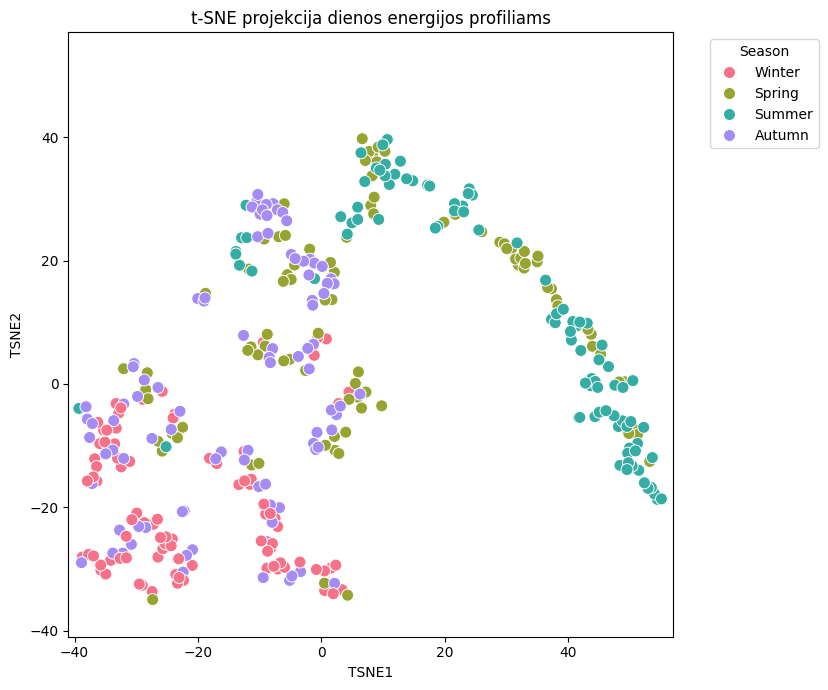

In [32]:
plt.figure(figsize=(10, 7))
lims = [
    min(np.floor(tsne_df['TSNE1'].min()), np.floor(tsne_df['TSNE2'].min())) - 1,
    max(np.ceil(tsne_df['TSNE1'].max()), np.ceil(tsne_df['TSNE2'].max())) + 1
]

plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')

sns.scatterplot(
    data=tsne_df,
    x='TSNE1',
    y='TSNE2',
    hue='season',
    palette='husl',
    s=75,
    hue_order=['Winter', 'Spring', 'Summer', 'Autumn']
)

plt.title('t-SNE projekcija dienos energijos profiliams')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()








In [33]:

X_emb_tsne = tsne_df[['TSNE1', 'TSNE2']].values

t = trustworthiness(X, X_emb_tsne, n_neighbors=10)
c = trustworthiness(X_emb_tsne, X, n_neighbors=10)

D_orig = pairwise_distances(X)
D_emb = pairwise_distances(X_emb_tsne)
stress = normalized_stress(X.values, X_emb_tsne)

print(f"Trustworthiness: {t:.4f}")
print(f"Continuity: {c:.4f}")
print(f"Stress: {stress:.4f}")










Trustworthiness: 0.9741
Continuity: 0.9757
Stress: 2.7456


      ## MDS

In [34]:

# def mds_grid_search(X, param_grid, n_neighbors=10, random_state=42):
#     grid = ParameterGrid(param_grid)
#     results = []
#     for params in grid:
#         mds = MDS(n_components=2, normalized_stress=True, n_jobs=-1, n_init=10, **params)
#         try:
#             X_emb_MDS = mds.fit_transform(X)
#             t = trustworthiness(X, X_emb_MDS, n_neighbors=n_neighbors)
#             c = trustworthiness(X_emb_MDS, X, n_neighbors=n_neighbors)
#             stress = mds.stress_
#             results.append({
#                 'params': params,
#                 'trustworthiness': t,
#                 'continuity': c,
#                 'stress': stress
#             })
#         except Exception as e:
#             print(f"Error with params {params}: {e}")
#             continue

#     return results

# param_grid = {'max_iter': [150, 200, 300, 500, 1000]}
# results = mds_grid_search(X, param_grid)
# for res in results:
#     print(res)







In [35]:
mds = MDS(n_components=2, max_iter=1000, normalized_stress=True)
mds_result = mds.fit_transform(X)
mds_df = pd.DataFrame(mds_result, columns=['MDS1', 'MDS2'])
mds_df['season'] = final_dataset_scaled['season'].values







c:\Users\danie\vizual2026\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\danie\vizual2026\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


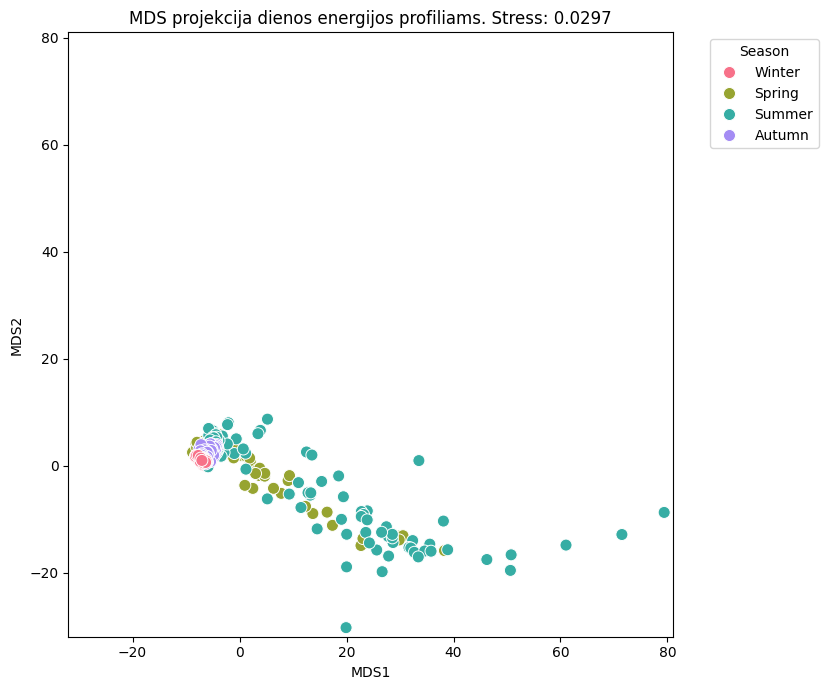

In [36]:

plt.figure(figsize=(10, 7))
lims = [
    min(np.floor(mds_df['MDS1'].min()), np.floor(mds_df['MDS2'].min())) - 1,
    max(np.ceil(mds_df['MDS1'].max()), np.ceil(mds_df['MDS2'].max())) + 1
]

plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')

sns.scatterplot(
    data=mds_df,
    x='MDS1',
    y='MDS2',
    hue='season',
    palette='husl',
    s=75,
    hue_order=['Winter', 'Spring', 'Summer', 'Autumn']
)

plt.title(f'MDS projekcija dienos energijos profiliams. Stress: {mds.stress_:.4f}')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()










In [37]:
X_emb_MDS = mds_df[['MDS1', 'MDS2']].values

t = trustworthiness(X, X_emb_MDS, n_neighbors=10)
c = trustworthiness(X_emb_MDS, X, n_neighbors=10)

print(f"Trustworthiness: {t:.4f}")
print(f"Continuity: {c:.4f}")
print(f"Stress: {mds.stress_:.4f}")










Trustworthiness: 0.9673
Continuity: 0.9835
Stress: 0.0297


 # Klasterizavimas

In [38]:
def draw_clusters(X_emb, labels, title):
	plt.figure(figsize=(10, 7))
	lims = [
		min(np.floor(X_emb[:, 0].min()), np.floor(X_emb[:, 1].min())) - 1,
		max(np.ceil(X_emb[:, 0].max()), np.ceil(X_emb[:, 1].max())) + 1
	]

	plt.xlim(lims)
	plt.ylim(lims)
	plt.gca().set_aspect('equal', adjustable='box')

	sns.scatterplot(
		x=X_emb[:, 0],
		y=X_emb[:, 1],
		hue=labels,
		palette='tab10',
		s=75,
		legend='full'
	)

	plt.title(title)
	plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
	plt.tight_layout()
	plt.show()



In [39]:



def stratified_sample_indices(strata_labels, sample_fraction, rng, min_total_size=None):
    strata_values = np.asarray(strata_labels)
    n_samples = len(strata_values)

    target_size = int(round(sample_fraction * n_samples))
    if min_total_size is not None:
        target_size = max(target_size, int(min_total_size))
    target_size = min(target_size, n_samples)

    sampled_parts = []
    for stratum in np.unique(strata_values):
        stratum_idx = np.where(strata_values == stratum)[0]
        n_take = int(round(sample_fraction * len(stratum_idx)))
        n_take = max(1, n_take)
        n_take = min(n_take, len(stratum_idx))
        sampled_parts.append(rng.choice(stratum_idx, size=n_take, replace=False))

    idx = np.sort(np.concatenate(sampled_parts))

    if len(idx) < target_size:
        remaining = np.setdiff1d(np.arange(n_samples), idx, assume_unique=False)
        add_n = min(target_size - len(idx), len(remaining))
        if add_n > 0:
            idx = np.sort(
                np.concatenate([idx, rng.choice(remaining, size=add_n, replace=False)])
            )

    if len(idx) > target_size:
        idx = np.sort(rng.choice(idx, size=target_size, replace=False))

    return idx


def stratified_sample_indices(strata_labels, sample_fraction, rng, min_total_size=None):
    strata_values = np.asarray(strata_labels)
    n_samples = len(strata_values)

    target_size = int(round(sample_fraction * n_samples))
    if min_total_size is not None:
        target_size = max(target_size, int(min_total_size))
    target_size = min(target_size, n_samples)

    sampled_parts = []
    for stratum in np.unique(strata_values):
        stratum_idx = np.where(strata_values == stratum)[0]
        n_take = int(round(sample_fraction * len(stratum_idx)))
        n_take = max(1, n_take)
        n_take = min(n_take, len(stratum_idx))
        sampled_parts.append(rng.choice(stratum_idx, size=n_take, replace=False))

    idx = np.sort(np.concatenate(sampled_parts))

    if len(idx) < target_size:
        remaining = np.setdiff1d(np.arange(n_samples), idx, assume_unique=False)
        add_n = min(target_size - len(idx), len(remaining))
        if add_n > 0:
            idx = np.sort(np.concatenate([idx, rng.choice(remaining, size=add_n, replace=False)]))

    if len(idx) > target_size:
        idx = np.sort(rng.choice(idx, size=target_size, replace=False))

    return idx


def run_clustering_stability(
    X_data,
    strata_labels,
    method="kmeans",
    param_values=None,
    n_runs=30,
    sample_fraction=0.8,
    base_seed=80085,
    linkage_method="ward",
    min_samples=5,
    max_noise_fraction=0.5,
):
    X_np = np.asarray(X_data)
    n_samples = X_np.shape[0]
    strata_values = np.asarray(strata_labels)
    row_ids_all = np.arange(n_samples)

    if param_values is None:
        param_values = np.round(np.arange(0.1, 3.05, 0.1), 2) if method == "dbscan" else range(2, 7)

    param_key = "eps" if method == "dbscan" else "k"
    all_assignments, all_run_metrics, all_ari_pairs, summary_rows = [], [], [], []

    for param in param_values:
        run_label_maps, run_row_sets = [], []

        for run in range(1, n_runs + 1):
            run_seed = base_seed + int(param * 1000) + run
            rng = np.random.default_rng(run_seed)

            idx = stratified_sample_indices(strata_values, sample_fraction, rng, min_total_size=int(param) + 1)
            X_run, row_ids_run = X_np[idx], row_ids_all[idx]

            if method == "kmeans":
                labels = KMeans(n_clusters=int(param), random_state=run_seed, n_init="auto").fit_predict(X_run)
            elif method == "hierarchical":
                labels = AgglomerativeClustering(n_clusters=int(param), linkage=linkage_method).fit_predict(X_run)
            elif method == "dbscan":
                labels = DBSCAN(eps=param, min_samples=min_samples).fit_predict(X_run)
            elif method == "kmedoids":
                dist_matrix = pairwise_distances(X_run)
                labels = KMedoids(n_clusters=int(param), random_state=run_seed,method="fasterpam").fit_predict(dist_matrix)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise    = (labels == -1).sum()
            mask       = labels != -1

            valid = n_clusters >= 2 and (method != "dbscan" or n_noise < len(labels) * max_noise_fraction)
            X_score, l_score = (X_run[mask], labels[mask]) if method == "dbscan" else (X_run, labels)

            try:    sil = silhouette_score(X_score, l_score) if valid else np.nan
            except: sil = np.nan
            try:    db  = davies_bouldin_score(X_score, l_score) if valid else np.nan
            except: db  = np.nan
            try:    ch  = calinski_harabasz_score(X_score, l_score) if valid else np.nan
            except: ch  = np.nan

            all_assignments.append(pd.DataFrame({param_key: param, "seed": run_seed, "row_id": row_ids_run, "cluster": labels}))
            all_run_metrics.append({param_key: param, "seed": run_seed, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch, "n_clusters": n_clusters, "n_noise": n_noise})
            run_label_maps.append(dict(zip(row_ids_run, labels)))
            run_row_sets.append(set(row_ids_run))

        k_ari_values = []
        for a, b in combinations(range(n_runs), 2):
            common = sorted(run_row_sets[a] & run_row_sets[b])
            if len(common) < 2:
                continue
            ari = adjusted_rand_score([run_label_maps[a][r] for r in common],
                                      [run_label_maps[b][r] for r in common])
            k_ari_values.append(ari)
            all_ari_pairs.append({param_key: param, "run_a": a+1, "run_b": b+1, "common_rows": len(common), "ari": ari})

        m = pd.DataFrame([r for r in all_run_metrics if r[param_key] == param])
        ari_arr = np.asarray(k_ari_values, dtype=float)
        summary_rows.append({
            param_key:             param,
            "mean_silhouette":     np.nanmean(m["silhouette"]),
            "std_silhouette":      np.nanstd(m["silhouette"], ddof=1),
            "mean_davies_bouldin": np.nanmean(m["davies_bouldin"]),
            "std_davies_bouldin":  np.nanstd(m["davies_bouldin"], ddof=1),
            "mean_calinski_harabasz": np.nanmean(m["calinski_harabasz"]),
            "std_calinski_harabasz":  np.nanstd(m["calinski_harabasz"], ddof=1),
            "mean_ari":            np.nanmean(ari_arr) if len(ari_arr) else np.nan,
            "std_ari":             np.nanstd(ari_arr, ddof=1) if len(ari_arr) > 1 else np.nan,
        })

    summary_df = pd.DataFrame(summary_rows)
    ranking = summary_df.dropna(subset=["mean_ari", "mean_silhouette", "mean_calinski_harabasz"]).sort_values(
        by=["mean_ari", "mean_silhouette", "mean_calinski_harabasz", "mean_davies_bouldin", "std_ari", "std_silhouette", param_key],
        ascending=[False, False, False, True, True, True, True],
    ).reset_index(drop=True)

    best = ranking[param_key].iloc[0] if not ranking.empty else None

    return {
        "assignments": pd.concat(all_assignments, ignore_index=True),
        "run_metrics": pd.DataFrame(all_run_metrics),
        "ari_pairs":   pd.DataFrame(all_ari_pairs),
        "summary":     summary_df,
        "ranking":     ranking,
        f"best_{param_key}": best,
    }





 # K-means

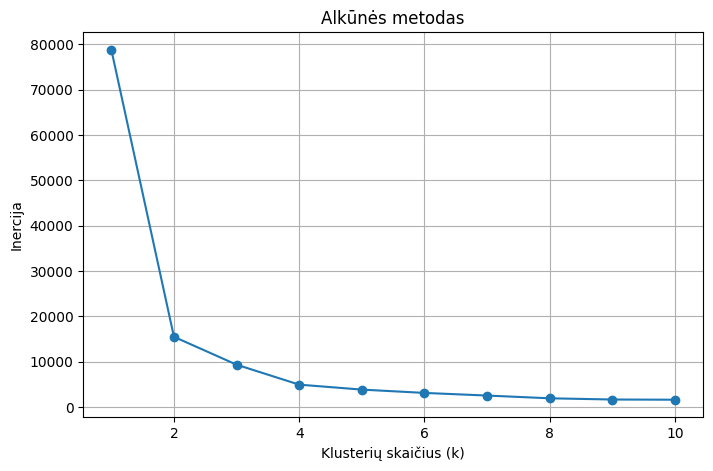

In [40]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=80085, n_init="auto")
    km.fit(X_emb_pca)
    inertias.append(km.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Klusterių skaičius (k)")
plt.ylabel("Inercija")
plt.title("Alkūnės metodas")
plt.grid(True)
plt.show()



In [ ]:
stability_results = run_clustering_stability(
    X_data=X_emb_pca,
    method="kmeans",
    strata_labels=final_dataset["season"],
    param_values=range(2, 7),
    n_runs=50,
    sample_fraction=0.8,
    base_seed=80085
)

cluster_assignments_runs = stability_results["assignments"]
k_run_metrics = stability_results["run_metrics"]
ari_pairs = stability_results["ari_pairs"]
stability_summary = stability_results["summary"]
best_k = stability_results["best_k"]

print("Stabilumo suvestinė pagal k:")
stability_summary




Stabilumo suvestinė pagal k:


,k,mean_silhouette,std_silhouette,mean_davies_bouldin,std_davies_bouldin,mean_calinski_harabasz,std_calinski_harabasz,mean_ari,std_ari
0,2,0.857350,0.005737,0.350453,0.013732,1195.306839,76.084137,0.977038,0.033453
1,3,0.828248,0.020448,0.541947,0.087911,1128.644924,111.823924,0.907195,0.065825
2,4,0.810033,0.012136,0.527348,0.038917,1397.672944,153.565123,0.947395,0.048021
3,5,0.784093,0.013960,0.625907,0.058040,1410.178899,166.675288,0.924158,0.052488
4,6,0.773136,0.016661,0.643966,0.086981,1428.042795,167.965417,0.933520,0.053277


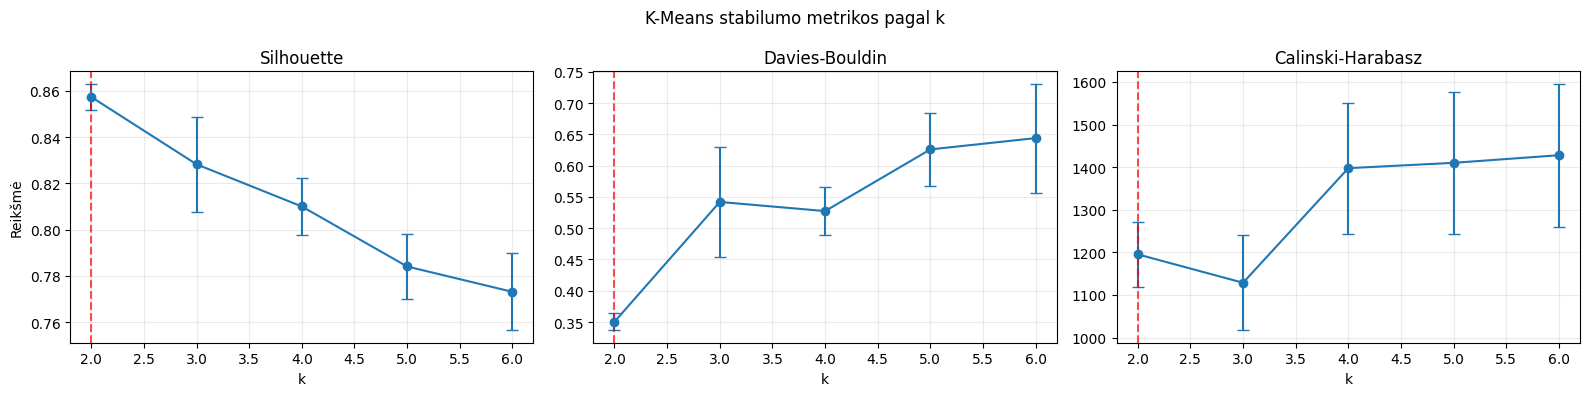

In [61]:
# Vizualus k palyginimas: vidurkiai ir sklaida (std) su pažymėtu rekomenduotu best_k.
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

axes[0].errorbar(
    stability_summary["k"],
    stability_summary["mean_silhouette"],
    yerr=stability_summary["std_silhouette"],
    fmt="o-",
    capsize=4,
)
axes[0].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[0].set_title("Silhouette")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Reikšmė")
axes[0].grid(True, alpha=0.25)

axes[1].errorbar(
    stability_summary["k"],
    stability_summary["mean_davies_bouldin"],
    yerr=stability_summary["std_davies_bouldin"],
    fmt="o-",
    capsize=4,
)
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Davies-Bouldin")
axes[1].set_xlabel("k")
axes[1].grid(True, alpha=0.25)

axes[2].errorbar(
    stability_summary["k"],
    stability_summary["mean_calinski_harabasz"],
    yerr=stability_summary["std_calinski_harabasz"],
    fmt="o-",
    capsize=4,
)
axes[2].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[2].set_title("Calinski-Harabasz")
axes[2].set_xlabel("k")
axes[2].grid(True, alpha=0.25)

plt.suptitle(f"K-Means stabilumo metrikos pagal k")
plt.tight_layout()
plt.show()



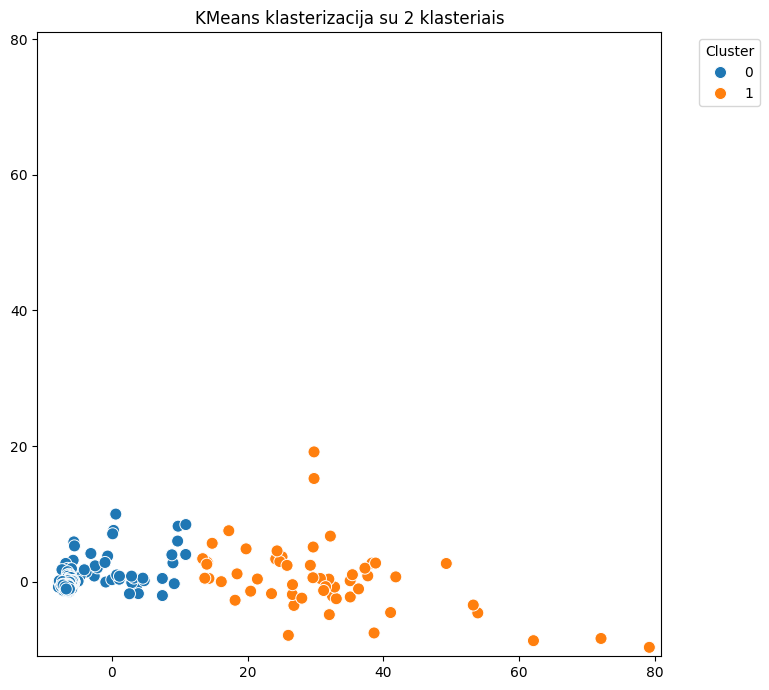

In [50]:
kmeans_model= KMeans(n_clusters=2, random_state=80085, n_init="auto").fit(X_emb_pca)
kmeans_labels = kmeans_model.labels_
draw_clusters(X_emb_pca, kmeans_labels, f"KMeans klasterizacija su {2} klasteriais")



In [51]:
kmeans_results= X_emb_pca.copy()
kmeans_results = pd.DataFrame(kmeans_results, columns=['Dim1', 'Dim2'])
kmeans_results['cluster'] = kmeans_labels
kmeans_results['real_labels']= final_dataset_scaled['season'].values
kmeans_results.head()




,Dim1,Dim2,cluster,real_labels
0,-6.605129,-1.295617,0,Winter
1,-7.503723,-0.635878,0,Winter
2,-6.776497,-0.973010,0,Winter
3,-7.128163,-1.115059,0,Winter
4,-7.427282,-0.634196,0,Winter


 <h1> HIERARCHINIS </h1>

Suggested k: 2


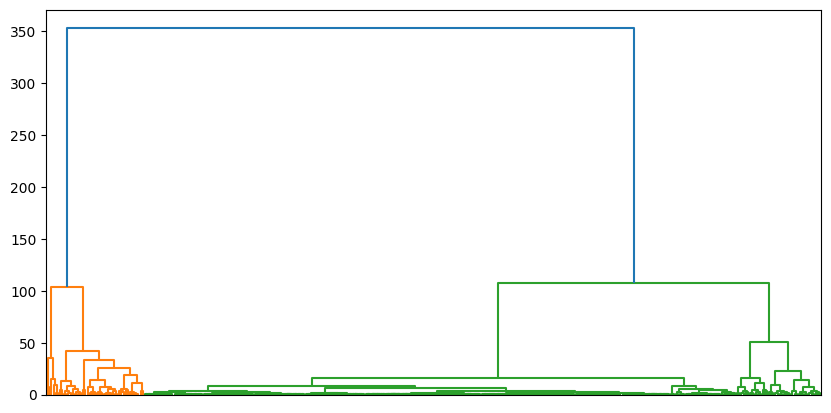

In [52]:
Z = linkage(X_emb_pca, method='ward')
last = Z[-10:, 2]          
acceleration = np.diff(last, 2)  
k = acceleration[::-1].argmax() + 2 

print(f"Suggested k: {k}")
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("")
plt.xticks([])
plt.show()






In [ ]:
#Applying the model here now
hierarchical_model = AgglomerativeClustering(n_clusters=2, linkage='ward')
hierarchical_clusters = hierarchical_model.fit_predict(X_emb_pca)





In [ ]:
hierarchical_results = final_dataset[["Day", "season"]].copy()
hierarchical_results["hierarchical_cluster"] = hierarchical_clusters
hierarchical_score_silhouette = silhouette_score(X_emb_pca, hierarchical_clusters)
hierarchical_score_davies_bouldin = davies_bouldin_score(X_emb_pca, hierarchical_clusters)
print(f"Silhouette Score Hierarchical Model for k=2: {hierarchical_score_silhouette:.4f}")
print(f"Davies-Bouldin Score Hierarchical Model for k=2: {hierarchical_score_davies_bouldin:.4f}")



In [ ]:
# # Kryžminė lentelė: cluster x season
# if 'hierarchical_results' in globals() and {'hierarchical_cluster', 'season'}.issubset(hierarchical_results.columns):
#     base_df = hierarchical_results[['hierarchical_cluster', 'season']].copy()
# elif {'hierarchical_cluster', 'season'}.issubset(final_dataset_scaled.columns):
#     base_df = final_dataset_scaled[['hierarchical_cluster', 'season']].copy()
# else:
#     raise ValueError("Nerandu stulpelių 'hierarchical_cluster' ir 'season'. Pirma paleisk klasterizacijos celes.")

# # Kiekiai
# ct_cluster_season = pd.crosstab(base_df['hierarchical_cluster'], base_df['season'], margins=True)
# print('Kryžminė lentelė (kiekiai): hierarchical_cluster x season')
# print(ct_cluster_season)

# # Eilučių procentai
# ct_cluster_season_row_pct = pd.crosstab(
#     base_df['hierarchical_cluster'],
#     base_df['season'],
#     normalize='index'
# ).round(4) * 100
# print('Kryžminė lentelė (eilutės %, cluster -> season):')
# print(ct_cluster_season_row_pct)

# # Stulpelių procentai
# ct_cluster_season_col_pct = pd.crosstab(
#     base_df['hierarchical_cluster'],
#     base_df['season'],
#     normalize='columns'
# ).round(4) * 100
# print('Kryžminė lentelė (stulpelai %, season -> cluster):')
# print(ct_cluster_season_col_pct)



In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(X_emb_pca[:, 0], X_emb_pca[:, 1], c=hierarchical_clusters, cmap='Set1', s=50, alpha=0.7)
plt.title("Hierarchinio klasterizavimo rezultatai (k=2)")

lim_min = min(X_emb_pca[:, 0].min(), X_emb_pca[:, 1].min()) - 1
lim_max = max(X_emb_pca[:, 0].max(), X_emb_pca[:, 1].max()) + 1
plt.xlim(lim_min, lim_max)
plt.ylim(lim_min, lim_max)

plt.show()






     <h1> DBSCAN </h1>

In [ ]:
for eps in np.arange(0.1, 5.1, 0.1):
    db = DBSCAN(eps=eps, min_samples=5).fit(X_emb_pca)
    labels = db.labels_

    mask = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    if n_clusters > 1 and mask.sum() > 1:
        sil = silhouette_score(X_emb_pca[mask], labels[mask])
        dbi = davies_bouldin_score(X_emb_pca[mask], labels[mask])
    else:
        sil, dbi = np.nan, np.nan

    print(f"eps={eps:.1f} → clusters={n_clusters}, noise={n_noise}, sil={sil:.3f}, db={dbi:.3f}")




   Geriausia silueta gavome:eps=2.1 → clusters=4, noise=52, sil=0.924, db=0.293









In [ ]:
dbscan_model = DBSCAN(eps=2.1, min_samples=5)
dbscan_clusters = dbscan_model.fit_predict(X_emb_pca)




In [ ]:
dbscan_results = final_dataset[["Day", "season"]].copy()
dbscan_results["dbscan_cluster"] = dbscan_clusters

mask = dbscan_clusters != -1

if len(set(dbscan_clusters[mask])) > 1:
    silhouette = silhouette_score(X_emb_pca[mask], dbscan_clusters[mask])
    db_index = davies_bouldin_score(X_emb_pca[mask], dbscan_clusters[mask])
else:
    silhouette = np.nan
    db_index = np.nan

print(f"Silhouette Score DBSCAN: {silhouette:.4f}")
print(f"Davies-Bouldin Score DBSCAN: {db_index:.4f}")
print(f"Number of clusters: {len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)}")
print(f"Noise points: {(dbscan_clusters == -1).sum()}")




In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 8))

plt.scatter(
    X_emb_pca[:, 0],
    X_emb_pca[:, 1],
    c=dbscan_clusters,
    cmap='Set1',
    s=50,
    alpha=0.7
)

plt.title("DBSCAN klasterizavimo rezultatai (eps=2.1)")

lim_min = min(X_emb_pca[:, 0].min(), X_emb_pca[:, 1].min()) - 1
lim_max = max(X_emb_pca[:, 0].max(), X_emb_pca[:, 1].max()) + 1
plt.xlim(lim_min, lim_max)
plt.ylim(lim_min, lim_max)

plt.show() #cia noise yra pilkai pavaizduoti




  # Kmedoids

In [53]:
stability_kmedoids = run_clustering_stability(
	X_data=X_emb_pca,
	method="kmedoids",
	strata_labels=final_dataset["season"],
	param_values=range(2, 7),
	n_runs=50,
	sample_fraction=0.8,
	base_seed=80085
)
stability_kmedoids_summary = stability_kmedoids["summary"]
best_kmedoids_k = stability_kmedoids["best_k"]
stability_kmedoids_summary



,k,mean_silhouette,std_silhouette,mean_davies_bouldin,std_davies_bouldin,mean_calinski_harabasz,std_calinski_harabasz,mean_ari,std_ari
0,2,0.857342,0.005708,0.353446,0.013373,1194.936352,76.288083,0.999332,0.003843
1,3,0.803320,0.008022,0.552219,0.019806,1026.922230,127.111424,0.936298,0.056936
2,4,0.787559,0.025901,0.595573,0.083180,1177.033001,287.861726,0.909595,0.065888
3,5,0.771487,0.010674,0.616536,0.061642,1404.594388,188.034959,0.966226,0.030025
4,6,0.695733,0.129905,0.716232,0.062008,1418.911757,207.639121,0.819008,0.229719


In [54]:
stability_kmedoids_summary = stability_kmedoids["summary"]
best_kmedoids_k = stability_kmedoids["best_k"]
stability_kmedoids_summary



,k,mean_silhouette,std_silhouette,mean_davies_bouldin,std_davies_bouldin,mean_calinski_harabasz,std_calinski_harabasz,mean_ari,std_ari
0,2,0.857342,0.005708,0.353446,0.013373,1194.936352,76.288083,0.999332,0.003843
1,3,0.803320,0.008022,0.552219,0.019806,1026.922230,127.111424,0.936298,0.056936
2,4,0.787559,0.025901,0.595573,0.083180,1177.033001,287.861726,0.909595,0.065888
3,5,0.771487,0.010674,0.616536,0.061642,1404.594388,188.034959,0.966226,0.030025
4,6,0.695733,0.129905,0.716232,0.062008,1418.911757,207.639121,0.819008,0.229719


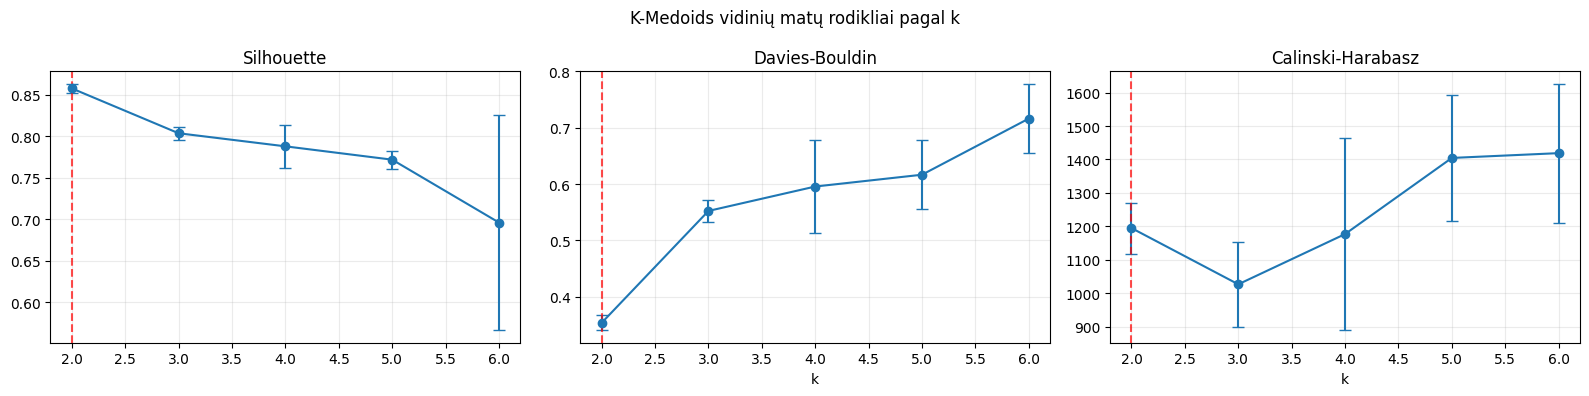

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
axes[0].set_title("Silhouette")
axes[0].errorbar(
	stability_kmedoids_summary["k"],
	stability_kmedoids_summary["mean_silhouette"],
	yerr=stability_kmedoids_summary["std_silhouette"],
	fmt="o-",
	capsize=4,
)
axes[0].axvline(best_kmedoids_k, color="red", linestyle="--", alpha=0.7)
axes[1].errorbar(
	stability_kmedoids_summary["k"],
	stability_kmedoids_summary["mean_davies_bouldin"],
	yerr=stability_kmedoids_summary["std_davies_bouldin"],
	fmt="o-",
	capsize=4,
)
axes[0].grid(True, alpha=0.25)

axes[1].axvline(best_kmedoids_k, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Davies-Bouldin")
axes[1].set_xlabel("k")
axes[1].grid(True, alpha=0.25)
axes[2].errorbar(
	stability_kmedoids_summary["k"],
	stability_kmedoids_summary["mean_calinski_harabasz"],
	yerr=stability_kmedoids_summary["std_calinski_harabasz"],
	fmt="o-",
	capsize=4,
)
axes[2].axvline(best_kmedoids_k, color="red", linestyle="--", alpha=0.7)
axes[2].set_title("Calinski-Harabasz")
axes[2].set_xlabel("k")
axes[2].grid(True, alpha=0.25)
plt.suptitle("K-Medoids vidinių matų rodikliai pagal k")
plt.tight_layout()
plt.show()



In [48]:
distances_emb=euclidean_distances(X_emb_pca)
kmedoids_model= KMedoids(n_clusters=2, random_state=80085, method="fasterpam").fit(distances_emb)
kmedoids_labels = kmedoids_model.labels_
kmedoids_results = final_dataset[["Day", "season"]].copy()
kmedoids_results["kmedoids_cluster"] = kmedoids_labels
kmedoids_results["real_labels"]= final_dataset_scaled['season'].values


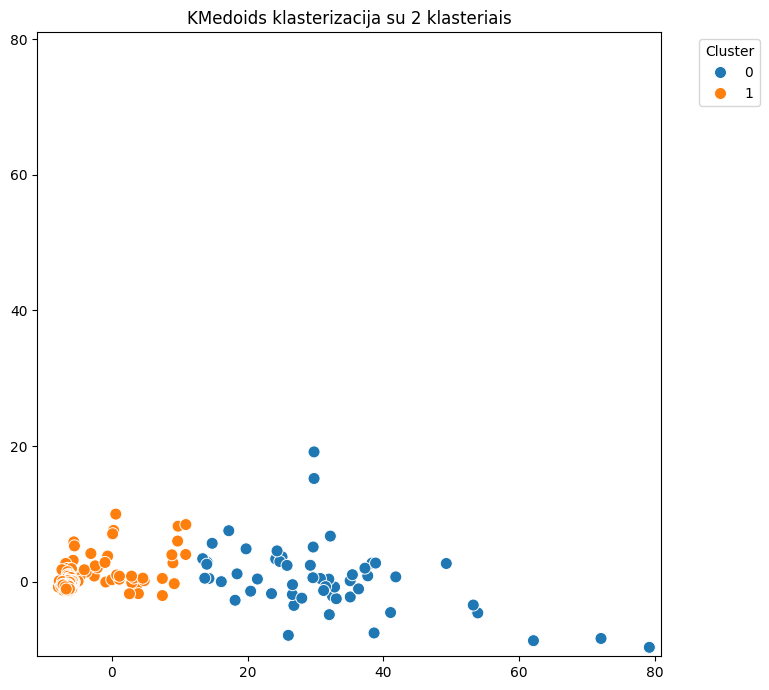

In [49]:
draw_clusters(X_emb_pca, kmedoids_labels, f"KMedoids klasterizacija su {2} klasteriais")



   <h1> Dimensijos mažinimas iki 8 dimensijų </h1>

In [ ]:
pca_model = PCA(n_components=8, random_state=80085)
pca_result = pca_model.fit_transform(X)
t = trustworthiness(X.values, pca_result, n_neighbors=8)
c = trustworthiness(pca_result, X.values, n_neighbors=8)

D_orig = pairwise_distances(X.values)
D_emb = pairwise_distances(X_emb_pca)
stress = normalized_stress(X.values, X_emb_pca)

print(f"Trustworthiness: {t:.4f}")
print(f"Continuity: {c:.4f}")
print(f"Stress: {stress:.4f}") # cia gauname labai geri rezultatai, todel kitu algoritmu netikriname, darome klasterizavima su PCA rezultatais




In [ ]:
plt.figure(figsize=(10, 7))
lims = [
    min(np.floor(X_pca_df['PC1'].min()), np.floor(X_pca_df['PC2'].min())) - 1,
    max(np.ceil(X_pca_df['PC1'].max()), np.ceil(X_pca_df['PC2'].max())) + 1
]

plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')

sns.scatterplot(
    data=X_pca_df,
    x='PC1',
    y='PC2',
    hue='season',
    palette='husl',
    s=75,
    hue_order=['Winter', 'Spring', 'Summer', 'Autumn']
)

plt.title('PCA projekcija dienos energijos profiliams')
plt.xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]*100:.2f}%)')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Explained variance ratio:', np.round(pca_model.explained_variance_ratio_, 4))




In [ ]:
X_pca_df_8 = pd.DataFrame(pca_result, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8'])
X_pca_df_8['season'] = final_dataset_scaled['season'].values

X_emb_pca_8 = X_pca_df_8[['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8']].values





   <h2> K-means </h2>

In [ ]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=80085, n_init="auto")
    km.fit(X_emb_pca_8)
    inertias.append(km.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Klusterių skaičius (k)")
plt.ylabel("Inercija")
plt.title("Alkūnės metodas (PCA su 8 komponentėmis)")
plt.grid(True)
plt.show()




In [ ]:
K_means_model_8 = KMeans(n_clusters=2, random_state=80085, n_init="auto")
clusters_8 = K_means_model_8.fit_predict(X_emb_pca_8)

silhouette_score_8 = silhouette_score(X_emb_pca_8, clusters_8)
print(f"Silhouette Score for k=2 (PCA 8 components): {silhouette_score_8:.4f}")
davies_bouldin_score_8 = davies_bouldin_score(X_emb_pca_8, clusters_8)
print(f"Davies-Bouldin Score for k=2 (PCA 8 components): {davies_bouldin_score_8:.4f}")




In [ ]:
stability_results_8 = run_clustering_stability(
    X_data=X_emb_pca_8,
    method="kmeans",
    strata_labels=final_dataset["season"],
    param_values=range(2, 7),
    n_runs=50,
    sample_fraction=0.8,
    base_seed=80085
)

cluster_assignments_runs = stability_results_8["assignments"]
k_run_metrics = stability_results_8["run_metrics"]
ari_pairs = stability_results_8["ari_pairs"]
stability_summary = stability_results_8["summary"]
best_k = stability_results_8["best_k"]

print("Stabilumo suvestinė pagal k:")
stability_summary




In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

axes[0].errorbar(
    stability_summary["k"],
    stability_summary["mean_silhouette"],
    yerr=stability_summary["std_silhouette"],
    fmt="o-",
    capsize=4,
)
axes[0].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[0].set_title("Silhouette")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Reikšmė")
axes[0].grid(True, alpha=0.25)

axes[1].errorbar(
    stability_summary["k"],
    stability_summary["mean_davies_bouldin"],
    yerr=stability_summary["std_davies_bouldin"],
    fmt="o-",
    capsize=4,
)
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Davies-Bouldin")
axes[1].set_xlabel("k")
axes[1].grid(True, alpha=0.25)

axes[2].errorbar(
    stability_summary["k"],
    stability_summary["mean_ari"],
    yerr=stability_summary["std_ari"],
    fmt="o-",
    capsize=4,
)
axes[2].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[2].set_title("ARI")
axes[2].set_xlabel("k")
axes[2].grid(True, alpha=0.25)

plt.suptitle(f"KMeans stabilumo metrikos pagal k")
plt.tight_layout()
plt.show()





   <h2> Hierarchinis </h2>

In [ ]:
Z = linkage(X_emb_pca_8, method='ward')
last = Z[-10:, 2]          
acceleration = np.diff(last, 2)  
k = acceleration[::-1].argmax() + 2 

print(f"Suggested k: {k}")
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("")
plt.xticks([])
plt.show()




In [ ]:
hierarchical_model_8 = AgglomerativeClustering(n_clusters=2, linkage='ward')
hierarchical_clusters_8 = hierarchical_model.fit_predict(X_emb_pca_8)

hierarchical_results_8 = final_dataset[["Day", "season"]].copy()
hierarchical_results_8["hierarchical_cluster"] = hierarchical_clusters_8
hierarchical_score_silhouette_8 = silhouette_score(X_emb_pca_8, hierarchical_clusters_8)
hierarchical_score_davies_bouldin_8 = davies_bouldin_score(X_emb_pca_8, hierarchical_clusters_8)
print(f"Silhouette Score Hierarchical Model for k=2: {hierarchical_score_silhouette_8:.4f}")
print(f"Davies-Bouldin Score Hierarchical Model for k=2: {hierarchical_score_davies_bouldin_8:.4f}")




In [ ]:
stability_results_8 = run_clustering_stability(
    X_data=X_emb_pca_8,
    method="hierarchical",         
    strata_labels=final_dataset["season"],
    param_values=range(2, 7),      
    n_runs=50,
    sample_fraction=0.8,
    base_seed=80085,
    linkage_method="ward"        
)

cluster_assignments_runs = stability_results_8["assignments"]
k_run_metrics = stability_results_8["run_metrics"]
ari_pairs = stability_results_8["ari_pairs"]
stability_summary= stability_results_8["summary"]
best_k = stability_results_8["best_k"]

print("Stabilumas pagal k (hierarchical):")
stability_summary




In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

axes[0].errorbar(
    stability_summary["k"],
    stability_summary["mean_silhouette"],
    yerr=stability_summary["std_silhouette"],
    fmt="o-",
    capsize=4,
)
axes[0].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[0].set_title("Silhouette")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Reikšmė")
axes[0].grid(True, alpha=0.25)

axes[1].errorbar(
    stability_summary["k"],
    stability_summary["mean_davies_bouldin"],
    yerr=stability_summary["std_davies_bouldin"],
    fmt="o-",
    capsize=4,
)
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Davies-Bouldin")
axes[1].set_xlabel("k")
axes[1].grid(True, alpha=0.25)

axes[2].errorbar(
    stability_summary["k"],
    stability_summary["mean_ari"],
    yerr=stability_summary["std_ari"],
    fmt="o-",
    capsize=4,
)
axes[2].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[2].set_title("ARI")
axes[2].set_xlabel("k")
axes[2].grid(True, alpha=0.25)

plt.suptitle(f"Hierarchical clustering stabilumo metrikos pagal k")  
plt.tight_layout()
plt.show()




     <h1> DBSCAN </h1>

In [ ]:
for eps in np.arange(0.1, 5.1, 0.1):
    db = DBSCAN(eps=eps, min_samples=5).fit(X_emb_pca)
    labels = db.labels_

    mask = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    if n_clusters > 1 and mask.sum() > 1:
        sil = silhouette_score(X_emb_pca[mask], labels[mask])
        dbi = davies_bouldin_score(X_emb_pca[mask], labels[mask])
    else:
        sil, dbi = np.nan, np.nan

    print(f"eps={eps:.1f} → clusters={n_clusters}, noise={n_noise}, sil={sil:.3f}, db={dbi:.3f}")




   Geriausia silueta gavome:eps=2.1 → clusters=4, noise=52, sil=0.924, db=0.293









In [ ]:
dbscan_model = DBSCAN(eps=2.1, min_samples=5)
dbscan_clusters = dbscan_model.fit_predict(X_emb_pca)




In [ ]:
dbscan_results = final_dataset[["Day", "season"]].copy()
dbscan_results["dbscan_cluster"] = dbscan_clusters

mask = dbscan_clusters != -1

if len(set(dbscan_clusters[mask])) > 1:
    silhouette = silhouette_score(X_emb_pca[mask], dbscan_clusters[mask])
    db_index = davies_bouldin_score(X_emb_pca[mask], dbscan_clusters[mask])
else:
    silhouette = np.nan
    db_index = np.nan

print(f"Silhouette Score DBSCAN: {silhouette:.4f}")
print(f"Davies-Bouldin Score DBSCAN: {db_index:.4f}")
print(f"Number of clusters: {len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)}")
print(f"Noise points: {(dbscan_clusters == -1).sum()}")




In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(
    X_emb_pca[:, 0],
    X_emb_pca[:, 1],
    c=dbscan_clusters,
    cmap='Set1',
    s=50,
    alpha=0.7
)

plt.title("DBSCAN klasterizavimo rezultatai (eps=2.1)")

lim_min = min(X_emb_pca[:, 0].min(), X_emb_pca[:, 1].min()) - 1
lim_max = max(X_emb_pca[:, 0].max(), X_emb_pca[:, 1].max()) + 1
plt.xlim(lim_min, lim_max)
plt.ylim(lim_min, lim_max)

plt.show() #cia noise yra pilkai pavaizduoti




 #  <h2> BDSCAN </h2>



In [ ]:
stability_results_8 = run_clustering_stability(
    X_data=X_emb_pca_8,
    method="dbscan",
    strata_labels=final_dataset["season"], 
    param_values=np.round(np.linspace(1.8, 2.2, 5), 2),
    n_runs=50,
    sample_fraction=0.8,
    base_seed=80085,
    min_samples=5,
    max_noise_fraction=0.5
)

cluster_assignments_runs = stability_results_8["assignments"]
dbscan_run_metrics = stability_results_8["run_metrics"]
ari_pairs = stability_results_8["ari_pairs"]
stability_summary = stability_results_8["summary"]
best_eps = stability_results_8["best_eps"]

print("Stabilumo suvestinė pagal eps (DBSCAN):")
stability_summary




In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

axes[0].errorbar(
    stability_summary["eps"],
    stability_summary["mean_silhouette"],
    yerr=stability_summary["std_silhouette"],
    fmt="o-",
    capsize=4,
)
axes[0].axvline(best_eps, color="red", linestyle="--", alpha=0.7)
axes[0].set_title("Silhouette")
axes[0].set_xlabel("eps")
axes[0].set_ylabel("Reikšmė")
axes[0].grid(True, alpha=0.25)

axes[1].errorbar(
    stability_summary["eps"],
    stability_summary["mean_davies_bouldin"],
    yerr=stability_summary["std_davies_bouldin"],
    fmt="o-",
    capsize=4,
)
axes[1].axvline(best_eps, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Davies-Bouldin")
axes[1].set_xlabel("eps")
axes[1].grid(True, alpha=0.25)

axes[2].errorbar(
    stability_summary["eps"],
    stability_summary["mean_ari"],
    yerr=stability_summary["std_ari"],
    fmt="o-",
    capsize=4,
)
axes[2].axvline(best_eps, color="red", linestyle="--", alpha=0.7)
axes[2].set_title("ARI")
axes[2].set_xlabel("eps")
axes[2].grid(True, alpha=0.25)

plt.suptitle("DBSCAN stabilumo metrikos pagal eps")
plt.tight_layout()
plt.show()




In [ ]:
dbscan_model_8 = DBSCAN(eps=2.1, min_samples=5)
dbscan_clusters_8 = dbscan_model_8.fit_predict(X_emb_pca_8)




In [ ]:
dbscan_results_8 = final_dataset[["Day", "season"]].copy()
dbscan_results_8["dbscan_cluster"] = dbscan_clusters_8

mask = dbscan_clusters_8 != -1

if len(set(dbscan_clusters_8[mask])) > 1:
    silhouette = silhouette_score(X_emb_pca_8[mask], dbscan_clusters_8[mask])
    db_index = davies_bouldin_score(X_emb_pca_8[mask], dbscan_clusters_8[mask])
else:
    silhouette = np.nan
    db_index = np.nan

print(f"Silhouette Score DBSCAN: {silhouette:.4f}")
print(f"Davies-Bouldin Score DBSCAN: {db_index:.4f}")
print(f"Number of clusters: {len(set(dbscan_clusters_8)) - (1 if -1 in dbscan_clusters_8 else 0)}")
print(f"Noise points: {(dbscan_clusters_8 == -1).sum()}")





   <h1> Klasterizavimas originalioje dimensijoje </h1>

   <h2> K-means </h2>

In [ ]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=80085, n_init="auto")
    km.fit(X)
    inertias.append(km.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Klusterių skaičius (k)")
plt.ylabel("Inercija")
plt.title("Alkūnės metodas (Originalioje dimensijoje)")
plt.grid(True)
plt.show()




In [ ]:
K_means_model_orig = KMeans(n_clusters=2, random_state=80085, n_init="auto")
clusters_orig = K_means_model_orig.fit_predict(X)

silhouette_score_orig = silhouette_score(X, clusters_orig)
print(f"Silhouette Score for k=2 (Originalioje dimensijoje): {silhouette_score_orig:.4f}")
davies_bouldin_score_orig = davies_bouldin_score(X, clusters_orig)
print(f"Davies-Bouldin Score for k=2 (Originalioje dimensijoje): {davies_bouldin_score_orig:.4f}")




In [ ]:
stability_results_orig = run_clustering_stability(
    X_data=X,
    method="kmeans",
    strata_labels=final_dataset["season"],
    param_values=range(2, 7),
    n_runs=50,
    sample_fraction=0.8,
    base_seed=80085
)

cluster_assignments_runs = stability_results_orig["assignments"]
k_run_metrics = stability_results_orig["run_metrics"]
ari_pairs = stability_results_orig["ari_pairs"]
stability_summary_orig = stability_results_orig["summary"]
best_k = stability_results_orig["best_k"]

print("Stabilumo suvestinė pagal k:")
stability_summary_orig




In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

axes[0].errorbar(
    stability_summary_orig["k"],
    stability_summary_orig["mean_silhouette"],
    yerr=stability_summary_orig["std_silhouette"],
    fmt="o-",
    capsize=4,
)
axes[0].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[0].set_title("Silhouette")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Reikšmė")
axes[0].grid(True, alpha=0.25)

axes[1].errorbar(
    stability_summary_orig["k"],
    stability_summary_orig["mean_davies_bouldin"],
    yerr=stability_summary_orig["std_davies_bouldin"],
    fmt="o-",
    capsize=4,
)
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Davies-Bouldin")
axes[1].set_xlabel("k")
axes[1].grid(True, alpha=0.25)

axes[2].errorbar(
    stability_summary_orig["k"],
    stability_summary_orig["mean_ari"],
    yerr=stability_summary_orig["std_ari"],
    fmt="o-",
    capsize=4,
)
axes[2].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[2].set_title("ARI")
axes[2].set_xlabel("k")
axes[2].grid(True, alpha=0.25)

plt.suptitle(f"KMeans stabilumo metrikos pagal k")
plt.tight_layout()
plt.show()





   <h2> Hierarchinis </h2>

In [ ]:
Z = linkage(X, method='ward')
last = Z[-10:, 2]          
acceleration = np.diff(last, 2)  
k = acceleration[::-1].argmax() + 2 

print(f"Suggested k: {k}")
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("")
plt.xticks([])
plt.show()




In [ ]:
hierarchical_model_orig = AgglomerativeClustering(n_clusters=2, linkage='ward')
hierarchical_clusters_orig = hierarchical_model.fit_predict(X)

hierarchical_results_orig = final_dataset[["Day", "season"]].copy()
hierarchical_results_orig["hierarchical_cluster"] = hierarchical_clusters_orig
hierarchical_score_silhouette_orig = silhouette_score(X, hierarchical_clusters_orig)
hierarchical_score_davies_bouldin_orig = davies_bouldin_score(X, hierarchical_clusters_orig)
print(f"Silhouette Score Hierarchical Model for k=2: {hierarchical_score_silhouette_orig:.4f}")
print(f"Davies-Bouldin Score Hierarchical Model for k=2: {hierarchical_score_davies_bouldin_orig:.4f}")




In [ ]:
stability_results_orig = run_clustering_stability(
    X_data=X,
    method="hierarchical",         
    strata_labels=final_dataset["season"],
    param_values=range(2, 7),      
    n_runs=50,
    sample_fraction=0.8,
    base_seed=80085,
    linkage_method="ward"        
)

cluster_assignments_runs = stability_results_orig["assignments"]
k_run_metrics = stability_results_orig["run_metrics"]
ari_pairs = stability_results_orig["ari_pairs"]
stability_summary_orig = stability_results_orig["summary"]
best_k = stability_results_orig["best_k"]

print("Stabilumo suvestinė pagal k (hierarchical):")
stability_summary_orig




In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

axes[0].errorbar(
    stability_summary_orig["k"],
    stability_summary_orig["mean_silhouette"],
    yerr=stability_summary_orig["std_silhouette"],
    fmt="o-",
    capsize=4,
)
axes[0].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[0].set_title("Silhouette")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Reikšmė")
axes[0].grid(True, alpha=0.25)

axes[1].errorbar(
    stability_summary_orig["k"],
    stability_summary_orig["mean_davies_bouldin"],
    yerr=stability_summary_orig["std_davies_bouldin"],
    fmt="o-",
    capsize=4,
)
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Davies-Bouldin")
axes[1].set_xlabel("k")
axes[1].grid(True, alpha=0.25)

axes[2].errorbar(
    stability_summary_orig["k"],
    stability_summary_orig["mean_ari"],
    yerr=stability_summary_orig["std_ari"],
    fmt="o-",
    capsize=4,
)
axes[2].axvline(best_k, color="red", linestyle="--", alpha=0.7)
axes[2].set_title("ARI")
axes[2].set_xlabel("k")
axes[2].grid(True, alpha=0.25)

plt.suptitle(f"Hierarchical clustering stabilumo metrikos pagal k")  # <-- changed
plt.tight_layout()
plt.show()




   <h2> BDSCAN </h2>

In [ ]:
stability_results_orig = run_clustering_stability(
    X_data=X,
    method="dbscan",
    strata_labels=final_dataset["season"], 
    param_values=np.round(np.linspace(1.8, 2.2, 5), 2),
    n_runs=50,
    sample_fraction=0.8,
    base_seed=80085,
    min_samples=5,
    max_noise_fraction=0.5
)

cluster_assignments_runs = stability_results_orig["assignments"]
dbscan_run_metrics = stability_results_orig["run_metrics"]
ari_pairs = stability_results_orig["ari_pairs"]
stability_summary_orig = stability_results_orig["summary"]
best_eps = stability_results_orig["best_eps"]

print("Stabilumo suvestinė pagal eps (DBSCAN):")
stability_summary_orig




In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

axes[0].errorbar(
    stability_summary_orig["eps"],
    stability_summary_orig["mean_silhouette"],
    yerr=stability_summary_orig["std_silhouette"],
    fmt="o-",
    capsize=4,
)
axes[0].axvline(best_eps, color="red", linestyle="--", alpha=0.7)
axes[0].set_title("Silhouette")
axes[0].set_xlabel("eps")
axes[0].set_ylabel("Reikšmė")
axes[0].grid(True, alpha=0.25)

axes[1].errorbar(
    stability_summary_orig["eps"],
    stability_summary_orig["mean_davies_bouldin"],
    yerr=stability_summary_orig["std_davies_bouldin"],
    fmt="o-",
    capsize=4,
)
axes[1].axvline(best_eps, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Davies-Bouldin")
axes[1].set_xlabel("eps")
axes[1].grid(True, alpha=0.25)

axes[2].errorbar(
    stability_summary_orig["eps"],
    stability_summary_orig["mean_ari"],
    yerr=stability_summary_orig["std_ari"],
    fmt="o-",
    capsize=4,
)
axes[2].axvline(best_eps, color="red", linestyle="--", alpha=0.7)
axes[2].set_title("ARI")
axes[2].set_xlabel("eps")
axes[2].grid(True, alpha=0.25)

plt.suptitle("DBSCAN stabilumo metrikos pagal eps")
plt.tight_layout()
plt.show()




In [ ]:
dbscan_model_orig = DBSCAN(eps=2.1, min_samples=5)
dbscan_clusters_orig = dbscan_model_orig.fit_predict(X)




In [ ]:
dbscan_results_orig= final_dataset[["Day", "season"]].copy()
dbscan_results_orig["dbscan_cluster"] = dbscan_clusters_orig

mask = dbscan_clusters_orig != -1

if len(set(dbscan_clusters_orig[mask])) > 1:
    silhouette = silhouette_score(X[mask], dbscan_clusters_orig[mask])
    db_index = davies_bouldin_score(X[mask], dbscan_clusters_orig[mask])
else:
    silhouette = np.nan
    db_index = np.nan

print(f"Silhouette Score DBSCAN: {silhouette:.4f}")
print(f"Davies-Bouldin Score DBSCAN: {db_index:.4f}")
print(f"Number of clusters: {len(set(dbscan_clusters_orig)) - (1 if -1 in dbscan_clusters_orig else 0)}")
print(f"Noise points: {(dbscan_clusters_orig == -1).sum()}")








